<a href="https://colab.research.google.com/github/lucmos2002/workshopGITHUB/blob/master/Trabalho_Final_LucasSouza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Trabalho Final do Curso de Ciência de Dados
# Nome: Lucas Martins de Oliveira Souza

# Este trabalho tem por finalidade uma análise detalhada das vendas de
# e-commerce brasileira.

# Fonte dos Dados: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?resource=download

Nesta etapa, foram importadas as bibliotecas que serão utilizadas, a princípio, na exploração dos bancos de dados a serem lidos.


In [ ]:
# Importação das Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Nesta etapa, foram escolhidas as planilhas de compras e de pagamentos para a criação dos dataframes que serão utilizados nestes trabalhos. Esses dados, posteriormente, serão combinados numa única base de dados.

In [ ]:
# Criação do DataFrame

df_order = pd.read_csv('/content/Trabalho_Final/olist_orders_dataset.csv')

df_payment = pd.read_csv('/content/Trabalho_Final/olist_order_payments_dataset.csv')

Análise Exploratória de Dados, para um entendimento maior dos dados dispostos em matéria de tipagem, por exemplo.

In [ ]:
# Entendimento dos Dados

df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
df_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
df_order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
df_payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Tratamento dos Dados, uma vez que a maioria das variáveis não serão consideradas para a modelagem das vendas deste trabalho.


In [ ]:
df_order.columns = ['id_pedido','id_consumidor','status_do_pedido','data_ordem_compra',
                    'data_aprovação_compra','data_entrega_transporte','data_entregue_cliente',
                    'data_entrega_estimada']

In [ ]:
df_payment.columns = ['id_pedido','sequência_pedido','forma_pagamento','forma_parcelamento',
                    'valor_do_pagamento']

In [ ]:
df_order.head()

,id_pedido,id_consumidor,status_do_pedido,data_ordem_compra,data_aprovação_compra,data_entrega_transporte,data_entregue_cliente,data_entrega_estimada
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
df_payment.head()

,id_pedido,sequência_pedido,forma_pagamento,forma_parcelamento,valor_do_pagamento
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
## Substituição do fomato da coluna 'data_venda'.

df_order['data_venda'] = pd.to_datetime(df_order['data_ordem_compra'])

df_order['dia_venda'] = df_order['data_venda'].dt.day

df_order['mês_venda'] = df_order['data_venda'].dt.month

df_order['ano_venda'] = df_order['data_venda'].dt.year

df_order.head()

,id_pedido,id_consumidor,status_do_pedido,data_ordem_compra,data_aprovação_compra,data_entrega_transporte,data_entregue_cliente,data_entrega_estimada,data_venda,dia_venda,mês_venda,ano_venda
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-02 10:56:33,2,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07-24 20:41:37,24,7,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-08 08:38:49,8,8,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11-18 19:28:06,18,11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02-13 21:18:39,13,2,2018


Eliminação de Colunas e Combinação dos Bancos de Dados

In [ ]:
# Eliminação de colunas desnecessárias para a análise e combinação do
# banco de dados de pedidos com o de pagamentos para análise.

df_venda = df_order

df_venda = df_venda.drop(['id_consumidor','status_do_pedido','data_ordem_compra','data_aprovação_compra',
              'data_entrega_transporte','data_entregue_cliente','data_entrega_estimada'], axis = 1)

df = df_venda.sort_values('data_venda')

df = pd.merge(df, df_payment[['id_pedido', 'valor_do_pagamento']], on='id_pedido', how='left')

df.head()

,id_pedido,data_venda,dia_venda,mês_venda,ano_venda,valor_do_pagamento
0,2e7a8482f6fb09756ca50c10d7bfc047,2016-09-04 21:15:19,4,9,2016,136.23
1,e5fa5a7210941f7d56d0208e4e071d35,2016-09-05 00:15:34,5,9,2016,75.06
2,809a282bbd5dbcabb6f2f724fca862ec,2016-09-13 15:24:19,13,9,2016,40.95
3,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,15,9,2016,NaN
4,71303d7e93b399f5bcd537d124c0bcfa,2016-10-02 22:07:52,2,10,2016,109.34


In [ ]:
# Total recebido por ano, tendo em vista que os dados começaram a ser colhidos
# no último trimestre de 2016.

df.groupby(['ano_venda'])['valor_do_pagamento'].sum()

,valor_do_pagamento
ano_venda,
2016,59362.34
2017,7249746.73
2018,8699763.05


In [ ]:
# Total recebido por mês e por ano, tendo em vista que os dados começaram ser
# colhidos no último trimestre de 2016.

df.groupby(['ano_venda','mês_venda'])['valor_do_pagamento'].sum()

ano_venda  mês_venda
2016       9                252.24
           10             59090.48
           12                19.62
2017       1             138488.04
           2             291908.01
           3             449863.60
           4             417788.03
           5             592918.82
           6             511276.38
           7             592382.92
           8             674396.32
           9             727762.45
           10            779677.88
           11           1194882.80
           12            878401.48
2018       1            1115004.18
           2             992463.34
           3            1159652.12
           4            1160785.48
           5            1153982.15
           6            1023880.50
           7            1066540.75
           8            1022425.32
           9               4439.54
           10               589.67
Name: valor_do_pagamento, dtype: float64

In [ ]:
# Média recebida por mês e por ano, tendo em vista que os dados começaram ser
# colhidos no último trimestre de 2016.

df.groupby(['ano_venda','mês_venda'])['valor_do_pagamento'].mean()

ano_venda  mês_venda
2016       9             84.080000
           10           172.779181
           12            19.620000
2017       1            162.927106
           2            154.776251
           3            158.570180
           4            162.500206
           5            150.334386
           6            148.799878
           7            137.220968
           8            148.218971
           9            161.152004
           10           160.427547
           11           151.962711
           12           149.007885
2018       1            147.428822
           2            142.759399
           3            154.373285
           4            161.018932
           5            161.735410
           6            159.507789
           7            163.906677
           8            152.646360
           9            277.471250
           10           147.417500
Name: valor_do_pagamento, dtype: float64

In [ ]:
# Desvio-padrão por mês e por ano, tendo em vista que os dados começaram ser
# colhidos no último trimestre de 2016. Pode-se perceber que, além dos dados
# estarem muito dispersos, há dados NaN em dezembro de 2016, que devem ser cor-
# rigidos.

df.groupby(['ano_venda','mês_venda'])['valor_do_pagamento'].std()

ano_venda  mês_venda
2016       9             48.276184
           10           202.190138
           12                  NaN
2017       1            229.848753
           2            277.466606
           3            252.672175
           4            270.432906
           5            229.648314
           6            224.490529
           7            164.347700
           8            189.551067
           9            288.655749
           10           221.674281
           11           204.303313
           12           181.368167
2018       1            181.611364
           2            171.418670
           3            195.139656
           4            220.366918
           5            231.218405
           6            218.685425
           7            259.558609
           8            217.468897
           9            539.530762
           10            72.811342
Name: valor_do_pagamento, dtype: float64

In [ ]:
# Detecção de NaN

# Pode-se perceber que há, pelo menos, um NaN na coluna 'valor_do_pagamento'.

df.isnull().any()

,0
id_pedido,False
data_venda,False
dia_venda,False
mês_venda,False
ano_venda,False
valor_do_pagamento,True


In [ ]:
# Substituição do NaN pela média dos valores dos pagamentos.

df.fillna(df['valor_do_pagamento'].mean(), inplace = True)

In [ ]:
df.isnull().any()

,0
id_pedido,False
data_venda,False
dia_venda,False
mês_venda,False
ano_venda,False
valor_do_pagamento,False


In [ ]:
# Evolução dos Dados Corrigidos

df_plot1 = round(df.groupby(['ano_venda'])['valor_do_pagamento'].sum(),2)

df_plot1

,valor_do_pagamento
ano_venda,
2016,59516.44
2017,7249746.73
2018,8699763.05


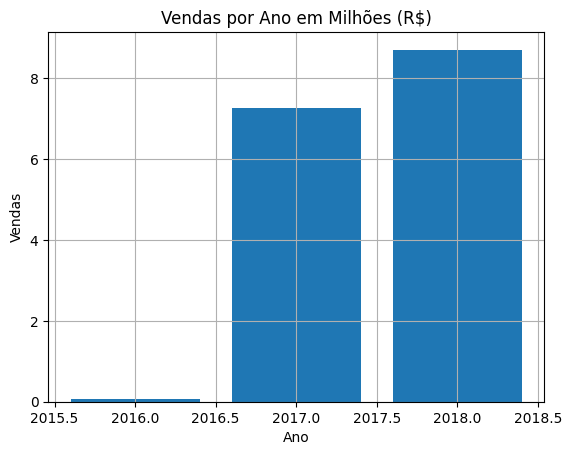

In [ ]:
# Plotagem das Vendas por Ano em um Gráfico de Barras

x = np.arange(2016,2019,1)

y = (df_plot1.values/1e6).round(2)

plt.bar(x,y)

plt.title('Vendas por Ano em Milhões (R$)')

plt.xlabel('Ano')

plt.ylabel('Vendas')

plt.grid()

plt.show()

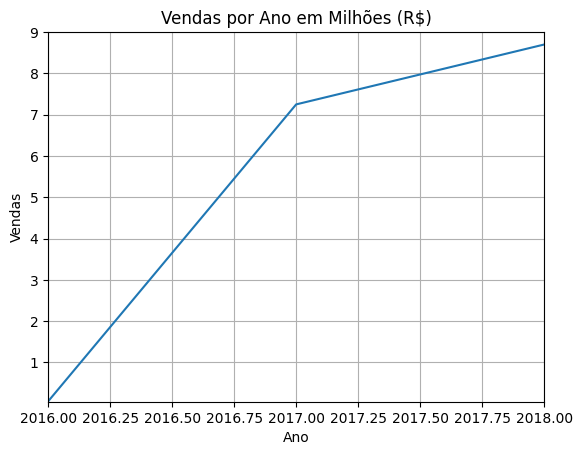

In [ ]:
# Plotagem das Vendas por Ano em um Gráfico XY

plt.plot(df_plot1.index,df_plot1.values/1e6)

plt.axis([2016, 2018, 5e-2, 9])

plt.title('Vendas por Ano em Milhões (R$)')

plt.xlabel('Ano')

plt.ylabel('Vendas')

plt.grid()

plt.show()

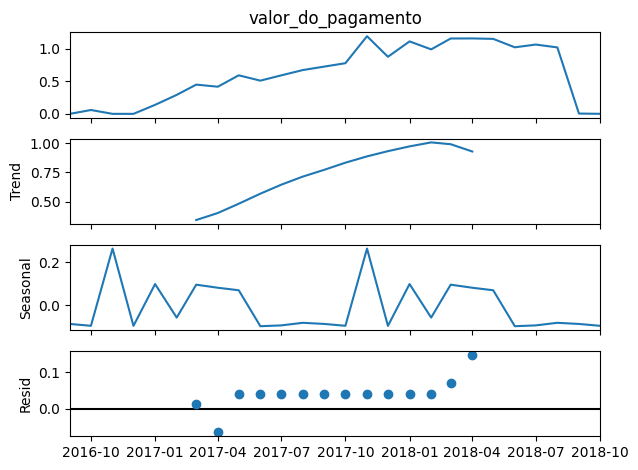

In [ ]:
# Para analisarmos as características da base de dados, é necessário, primeira
# mente, decompor a base de dados, assumida sua sazonabildade.

from statsmodels.tsa.seasonal import seasonal_decompose

# Criar um DateTimeIndex com frequência mensal

df_temps = df.drop(['id_pedido','dia_venda','mês_venda','ano_venda'], axis = 1)

df_temps = df_temps.set_index('data_venda')

# Re-amostrar os dados para frequência mensal

df_temps_mensal = (df_temps['valor_do_pagamento']/1e6).resample('MS').sum()

# Decompor a série sazonal

decomposição = seasonal_decompose(df_temps_mensal, model='additive')

# Plotar as componentes

decomposição.plot()

plt.show()

Uma vez que estamos tratando de um fenômeno que se reproduz ao longo do tempo, serão escolhidos dois modelos indicados para a reprodução de séries temporais:
ARIMA e OLS.

In [ ]:
import statsmodels.api as sm

In [ ]:
# Criar um modelo ARIMA, supondo AR(1), I(1) e MA(1), ou seja, componente
# auto-regressivo de primeira ordem, tendência e previsibilidade do erro
# atual com o anterior.

model = sm.tsa.ARIMA(df['valor_do_pagamento'], order=(1,1,1))

results = model.fit()

In [ ]:
forecast = results.forecast(steps=24)

In [ ]:
# Criar um modelo OLS.

# Separação das variáveis

X = df_temps.index.month

y = df_temps['valor_do_pagamento']

# Criação do modelo

model = sm.OLS(y, X).fit()

In [ ]:
predict = model.predict(X)

Cálculo dos Erros Médios Quadráticos dos Modelos ARIMA e OLS

In [ ]:
# RMSE ARIMA

rmse_arima = round(np.sqrt(np.mean((forecast.values - df_temps_mensal.values[-24:])**2)),2)

rmse_arima

136.89

In [ ]:
X_test = X[-24:]

predict_test = model.predict(X_test)

In [ ]:
# RMSE OLS

rmse_ols = round(np.sqrt(np.mean((predict_test - df_temps_mensal.values[-24:])**2)),2)

rmse_ols

178.76

Pode-se perceber que o Modelo ARIMA resultou numa melhor abordagem, apesar da dispersão dos dados.

Para se comparar os resultados de ambos os modelos, foi escolhido um intervalo com os últimos 24 dados para se comparar os dois modelos.


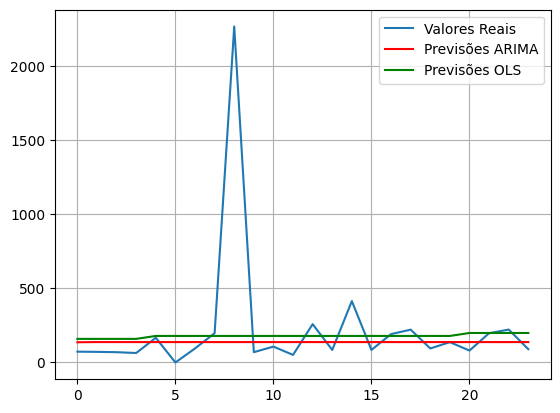

In [ ]:
y_test = df_temps.values[-24:]

y_arima = forecast.values

y_ols = predict_test

plt.plot(y_test, label='Valores Reais')

plt.plot(y_arima, color = 'red', label='Previsões ARIMA')

plt.plot(y_ols, color = 'green', label='Previsões OLS')

plt.grid()

plt.legend()

plt.show()

In [ ]:
df_temps.tail(24)

,valor_do_pagamento
data_venda,
2018-08-30 10:24:34,72.98
2018-08-30 13:07:46,71.61
2018-08-30 15:11:58,69.46
2018-08-31 16:13:44,63.89
2018-09-03 09:06:57,166.46
2018-09-03 14:14:25,0.00
2018-09-03 18:40:50,94.63
2018-09-03 18:45:34,197.55
2018-09-06 10:48:12,2266.61
